# 03 - Train Classical Baselines

This notebook trains classical ML baselines across **three feature sets** and reports cross-validated metrics including **AUC-ROC** and **AUC-PR** for the CIC-IDS2017 elephant/mice task.

**Feature Sets:**
1. **Baseline** (paper-faithful, leaky): includes `bidirectional_bytes` → target: `target_traffic` (Chebyshev)
2. **Non-leaky**: removes byte features → target: `target_99pct` (99th percentile)
3. **Early**: coarse structural features only → target: `target_99pct`

**Outputs**
- Table 3: averaged metrics (accuracy/precision/recall/F1/**AUC-ROC**/**AUC-PR**) across 5 stratified group folds for each feature set.
- Figure 7: bar chart comparing F1 scores across feature sets.
- Figure 8: ROC and PR curves for best models per feature set.
- Figure 9: confusion matrices for best models per feature set.
- Figure 10: random-forest feature importance plot for non-leaky features.
- Markdown summary comparing feature sets and discussing leakage effects.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# Ensure project root is on sys.path before importing package modules
try:
    PROJECT_ROOT = Path.cwd()
except FileNotFoundError:
    PROJECT_ROOT = Path("/Users/mohammadmalik/Documents/Development/GitHub/elephant-mice-cicids2017")

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CONFIG
from src.models.classical_baselines import run_baselines

plt.style.use("seaborn-v0_8-colorblind")

FEATURE_SETS = ["baseline", "non_leaky", "early"]
FEATURE_SET_COLORS = {"baseline": "#4c72b0", "non_leaky": "#55a868", "early": "#c44e52"}

In [2]:
# Run training across all feature sets
all_results = {}
all_predictions = {}

for fs in FEATURE_SETS:
    print(f"\n{'='*60}")
    print(f"Training feature_set={fs}")
    print(f"{'='*60}")
    agg, preds = run_baselines(feature_set=fs)
    all_results[fs] = agg
    all_predictions[fs] = preds

print("\n✓ Training complete for all feature sets")


Training feature_set=baseline


2025-11-28 13:14:34 - INFO - Feature set=baseline | target=target_traffic | dataset size=55726 | positive fraction=0.0879%
2025-11-28 13:14:34 - INFO - Class priors: {0: '99.9121%', 1: '0.0879%'}
2025-11-28 13:14:34 - INFO - Evaluating log_reg via 5-fold StratifiedGroupKFold
2025-11-28 13:14:39 - INFO - Fold 1 (log_reg) | train=48994 test=6732 | elephants in test=4
2025-11-28 13:14:39 - INFO - Fold 2 (log_reg) | train=39619 test=16107 | elephants in test=7
2025-11-28 13:14:39 - INFO - Fold 3 (log_reg) | train=44721 test=11005 | elephants in test=13
2025-11-28 13:14:39 - INFO - Fold 4 (log_reg) | train=44806 test=10920 | elephants in test=14
2025-11-28 13:14:39 - INFO - Fold 5 (log_reg) | train=44764 test=10962 | elephants in test=11
2025-11-28 13:14:39 - INFO - Evaluating svm_rbf via 5-fold StratifiedGroupKFold
2025-11-28 13:14:45 - INFO - Fold 1 (svm_rbf) | train=48994 test=6732 | elephants in test=4
2025-11-28 13:14:45 - INFO - Fold 2 (svm_rbf) | train=39619 test=16107 | elephants in

# Baseline results – feature_set=baseline (5-fold stratified group CV)

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC | AUC-PR |
| --- | --- | --- | --- | --- | --- | --- |
| rf | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 0.9846 ± 0.0308 | 0.9920 ± 0.0160 | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 |
| dt | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 0.9846 ± 0.0308 | 0.9920 ± 0.0160 | 0.9923 ± 0.0154 | 0.9846 ± 0.0307 |
| svm_rbf | 0.9999 ± 0.0001 | 0.9600 ± 0.0800 | 0.9571 ± 0.0571 | 0.9550 ± 0.0436 | 1.0000 ± 0.0000 | 0.9946 ± 0.0071 |
| log_reg | 0.9999 ± 0.0001 | 1.0000 ± 0.0000 | 0.9110 ± 0.0885 | 0.9511 ± 0.0497 | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 |
| knn | 0.9999 ± 0.0001 | 0.9600 ± 0.0800 | 0.9286 ± 0.1107 | 0.9370 ± 0.0658 | 0.9857 ± 0.0286 | 0.9705 ± 0.0567 |
| lda | 0.9996 ± 0.0003 | 1.0000 ± 0.0000 | 0.5810 ± 0.2932 | 0.6926 ± 0.2294 | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 |
| gnb | 0.9991 ± 0.0003 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.8340 ± 0.1020 | 0.7295 ± 0.2373 |


2025-11-28 13:15:16 - INFO - Feature set=non_leaky | target=target_99pct | dataset size=55726 | positive fraction=0.8344%
2025-11-28 13:15:16 - INFO - Class priors: {0: '99.1656%', 1: '0.8344%'}
2025-11-28 13:15:16 - INFO - Evaluating log_reg via 5-fold StratifiedGroupKFold
2025-11-28 13:15:20 - INFO - Fold 1 (log_reg) | train=48970 test=6756 | elephants in test=50
2025-11-28 13:15:21 - INFO - Fold 2 (log_reg) | train=39726 test=16000 | elephants in test=105
2025-11-28 13:15:21 - INFO - Fold 3 (log_reg) | train=44704 test=11022 | elephants in test=105
2025-11-28 13:15:21 - INFO - Fold 4 (log_reg) | train=44774 test=10952 | elephants in test=103
2025-11-28 13:15:21 - INFO - Fold 5 (log_reg) | train=44730 test=10996 | elephants in test=102
2025-11-28 13:15:22 - INFO - Evaluating svm_rbf via 5-fold StratifiedGroupKFold
2025-11-28 13:15:28 - INFO - Fold 1 (svm_rbf) | train=48970 test=6756 | elephants in test=50
2025-11-28 13:15:29 - INFO - Fold 2 (svm_rbf) | train=39726 test=16000 | elepha

# Baseline results – feature_set=non_leaky (5-fold stratified group CV)

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC | AUC-PR |
| --- | --- | --- | --- | --- | --- | --- |
| rf | 0.9992 ± 0.0002 | 0.9701 ± 0.0171 | 0.9343 ± 0.0196 | 0.9516 ± 0.0093 | 0.9941 ± 0.0057 | 0.9801 ± 0.0082 |
| dt | 0.9989 ± 0.0004 | 0.9393 ± 0.0390 | 0.9279 ± 0.0335 | 0.9332 ± 0.0311 | 0.9637 ± 0.0168 | 0.8728 ± 0.0575 |
| svm_rbf | 0.9986 ± 0.0002 | 0.9885 ± 0.0104 | 0.8425 ± 0.0255 | 0.9095 ± 0.0162 | 0.9927 ± 0.0078 | 0.9783 ± 0.0093 |
| log_reg | 0.9983 ± 0.0005 | 0.9604 ± 0.0343 | 0.8348 ± 0.0322 | 0.8927 ± 0.0259 | 0.9960 ± 0.0037 | 0.9586 ± 0.0210 |
| knn | 0.9983 ± 0.0003 | 0.9479 ± 0.0114 | 0.8431 ± 0.0471 | 0.8916 ± 0.0239 | 0.9804 ± 0.0090 | 0.9314 ± 0.0202 |
| lda | 0.9931 ± 0.0021 | 0.6425 ± 0.1976 | 0.5593 ± 0.0191 | 0.5850 ± 0.0823 | 0.9776 ± 0.0138 | 0.6805 ± 0.1331 |
| gnb | 0.9910 ± 0.0060 | 0.6849 ± 0.2926 | 0.5767 ± 0.1357 | 0.5550 ± 0.0892 | 0.9821 ± 0.0095 | 0.6446 ± 0.0225 |

2025-11-28 13:16:04 - INFO - Feature set=early | target=target_99pct | dataset size=55726 | positive fraction=0.8344%
2025-11-28 13:16:04 - INFO - Class priors: {0: '99.1656%', 1: '0.8344%'}
2025-11-28 13:16:04 - INFO - Evaluating log_reg via 5-fold StratifiedGroupKFold
2025-11-28 13:16:08 - INFO - Fold 1 (log_reg) | train=48970 test=6756 | elephants in test=50
2025-11-28 13:16:08 - INFO - Fold 2 (log_reg) | train=39726 test=16000 | elephants in test=105
2025-11-28 13:16:08 - INFO - Fold 3 (log_reg) | train=44704 test=11022 | elephants in test=105
2025-11-28 13:16:08 - INFO - Fold 4 (log_reg) | train=44774 test=10952 | elephants in test=103
2025-11-28 13:16:08 - INFO - Fold 5 (log_reg) | train=44730 test=10996 | elephants in test=102
2025-11-28 13:16:08 - INFO - Evaluating svm_rbf via 5-fold StratifiedGroupKFold
2025-11-28 13:16:15 - INFO - Fold 1 (svm_rbf) | train=48970 test=6756 | elephants in test=50
2025-11-28 13:16:16 - INFO - Fold 2 (svm_rbf) | train=39726 test=16000 | elephants 

# Baseline results – feature_set=early (5-fold stratified group CV)

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC | AUC-PR |
| --- | --- | --- | --- | --- | --- | --- |
| rf | 0.9983 ± 0.0003 | 0.9007 ± 0.0182 | 0.8989 ± 0.0127 | 0.8997 ± 0.0138 | 0.9889 ± 0.0037 | 0.9399 ± 0.0198 |
| knn | 0.9976 ± 0.0008 | 0.8592 ± 0.0843 | 0.8644 ± 0.0307 | 0.8585 ± 0.0411 | 0.9725 ± 0.0075 | 0.8818 ± 0.0336 |
| log_reg | 0.9978 ± 0.0005 | 0.9361 ± 0.0225 | 0.7903 ± 0.0348 | 0.8564 ± 0.0204 | 0.9953 ± 0.0043 | 0.9352 ± 0.0288 |
| dt | 0.9975 ± 0.0005 | 0.8579 ± 0.0273 | 0.8472 ± 0.0351 | 0.8515 ± 0.0091 | 0.9230 ± 0.0174 | 0.7273 ± 0.0150 |
| svm_rbf | 0.9975 ± 0.0005 | 0.9187 ± 0.0412 | 0.7730 ± 0.0414 | 0.8383 ± 0.0265 | 0.9862 ± 0.0072 | 0.9320 ± 0.0207 |
| gnb | 0.9800 ± 0.0056 | 0.3041 ± 0.0577 | 0.9847 ± 0.0156 | 0.4613 ± 0.0696 | 0.9914 ± 0.0073 | 0.6640 ± 0.1188 |
| lda | 0.9933 ± 0.0014 | 0.8870 ± 0.2261 | 0.2397 ± 0.1261 | 0.3601 ± 0.1495 | 0.9572 ± 0.0229 | 0.5962 ± 0.1908 |

✓ 

In [3]:
# Table 3: Results for each feature set with AUC metrics
def make_metrics_table(results, feature_set_name):
    def _fmt(mean, std):
        return f"{mean:.4f} ± {std:.4f}"
    def _fmt_opt(mean, std):
        if mean is None or std is None:
            return "N/A"
        return f"{mean:.4f} ± {std:.4f}"
    
    rows = []
    for res in results:
        rows.append({
            "Model": res.model,
            "Accuracy": _fmt(res.accuracy_mean, res.accuracy_std),
            "Precision": _fmt(res.precision_mean, res.precision_std),
            "Recall": _fmt(res.recall_mean, res.recall_std),
            "F1": _fmt(res.f1_mean, res.f1_std),
            "AUC-ROC": _fmt_opt(res.auc_roc_mean, res.auc_roc_std),
            "AUC-PR": _fmt_opt(res.auc_pr_mean, res.auc_pr_std),
        })
    return pd.DataFrame(rows)

for fs in FEATURE_SETS:
    print(f"\n### Feature Set: {fs}")
    display(make_metrics_table(all_results[fs], fs))



### Feature Set: baseline


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,rf,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9846 ± 0.0308,0.9920 ± 0.0160,1.0000 ± 0.0000,1.0000 ± 0.0000
1,dt,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9846 ± 0.0308,0.9920 ± 0.0160,0.9923 ± 0.0154,0.9846 ± 0.0307
2,svm_rbf,0.9999 ± 0.0001,0.9600 ± 0.0800,0.9571 ± 0.0571,0.9550 ± 0.0436,1.0000 ± 0.0000,0.9946 ± 0.0071
3,log_reg,0.9999 ± 0.0001,1.0000 ± 0.0000,0.9110 ± 0.0885,0.9511 ± 0.0497,1.0000 ± 0.0000,1.0000 ± 0.0000
4,knn,0.9999 ± 0.0001,0.9600 ± 0.0800,0.9286 ± 0.1107,0.9370 ± 0.0658,0.9857 ± 0.0286,0.9705 ± 0.0567
5,lda,0.9996 ± 0.0003,1.0000 ± 0.0000,0.5810 ± 0.2932,0.6926 ± 0.2294,1.0000 ± 0.0000,1.0000 ± 0.0000
6,gnb,0.9991 ± 0.0003,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.8340 ± 0.1020,0.7295 ± 0.2373



### Feature Set: non_leaky


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,rf,0.9992 ± 0.0002,0.9701 ± 0.0171,0.9343 ± 0.0196,0.9516 ± 0.0093,0.9941 ± 0.0057,0.9801 ± 0.0082
1,dt,0.9989 ± 0.0004,0.9393 ± 0.0390,0.9279 ± 0.0335,0.9332 ± 0.0311,0.9637 ± 0.0168,0.8728 ± 0.0575
2,svm_rbf,0.9986 ± 0.0002,0.9885 ± 0.0104,0.8425 ± 0.0255,0.9095 ± 0.0162,0.9927 ± 0.0078,0.9783 ± 0.0093
3,log_reg,0.9983 ± 0.0005,0.9604 ± 0.0343,0.8348 ± 0.0322,0.8927 ± 0.0259,0.9960 ± 0.0037,0.9586 ± 0.0210
4,knn,0.9983 ± 0.0003,0.9479 ± 0.0114,0.8431 ± 0.0471,0.8916 ± 0.0239,0.9804 ± 0.0090,0.9314 ± 0.0202
5,lda,0.9931 ± 0.0021,0.6425 ± 0.1976,0.5593 ± 0.0191,0.5850 ± 0.0823,0.9776 ± 0.0138,0.6805 ± 0.1331
6,gnb,0.9910 ± 0.0060,0.6849 ± 0.2926,0.5767 ± 0.1357,0.5550 ± 0.0892,0.9821 ± 0.0095,0.6446 ± 0.0225



### Feature Set: early


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,rf,0.9983 ± 0.0003,0.9007 ± 0.0182,0.8989 ± 0.0127,0.8997 ± 0.0138,0.9889 ± 0.0037,0.9399 ± 0.0198
1,knn,0.9976 ± 0.0008,0.8592 ± 0.0843,0.8644 ± 0.0307,0.8585 ± 0.0411,0.9725 ± 0.0075,0.8818 ± 0.0336
2,log_reg,0.9978 ± 0.0005,0.9361 ± 0.0225,0.7903 ± 0.0348,0.8564 ± 0.0204,0.9953 ± 0.0043,0.9352 ± 0.0288
3,dt,0.9975 ± 0.0005,0.8579 ± 0.0273,0.8472 ± 0.0351,0.8515 ± 0.0091,0.9230 ± 0.0174,0.7273 ± 0.0150
4,svm_rbf,0.9975 ± 0.0005,0.9187 ± 0.0412,0.7730 ± 0.0414,0.8383 ± 0.0265,0.9862 ± 0.0072,0.9320 ± 0.0207
5,gnb,0.9800 ± 0.0056,0.3041 ± 0.0577,0.9847 ± 0.0156,0.4613 ± 0.0696,0.9914 ± 0.0073,0.6640 ± 0.1188
6,lda,0.9933 ± 0.0014,0.8870 ± 0.2261,0.2397 ± 0.1261,0.3601 ± 0.1495,0.9572 ± 0.0229,0.5962 ± 0.1908


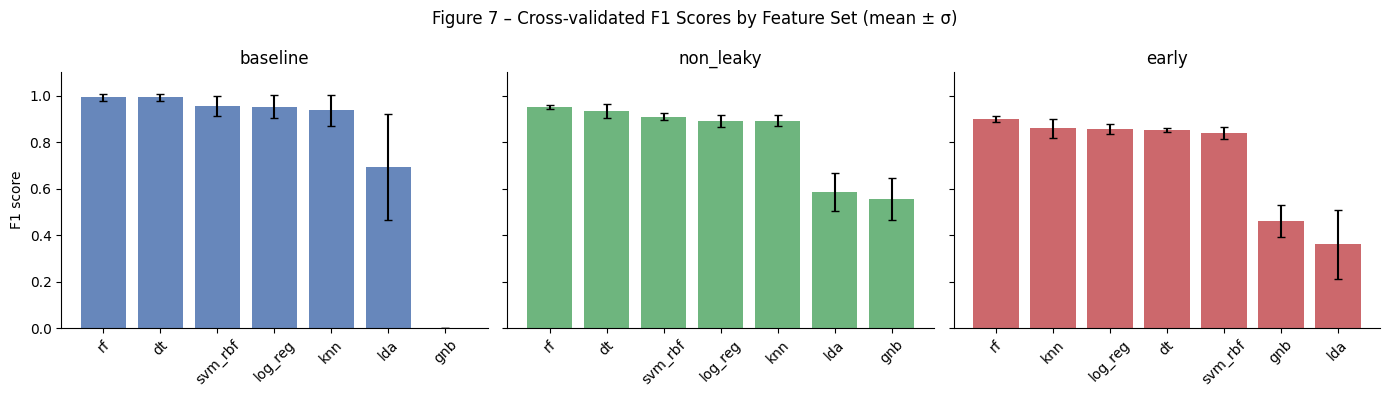

In [ ]:
# Figure 7: F1 score comparison across feature sets
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for idx, fs in enumerate(FEATURE_SETS):
    ax = axes[idx]
    results = all_results[fs]
    models = [res.model for res in results]
    f1_means = [res.f1_mean for res in results]
    f1_stds = [res.f1_std for res in results]
    
    ax.bar(models, f1_means, yerr=f1_stds, color=FEATURE_SET_COLORS[fs], alpha=0.85, capsize=3)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("F1 score" if idx == 0 else "")
    ax.set_title(f"{fs}")
    ax.tick_params(axis='x', rotation=45)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle("Figure 7 - Cross-validated F1 Scores by Feature Set (mean ± σ)", fontsize=12)
plt.tight_layout()
plt.show()


/opt/homebrew/Caskroom/miniconda/base/envs/DL/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/DL/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/DL/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


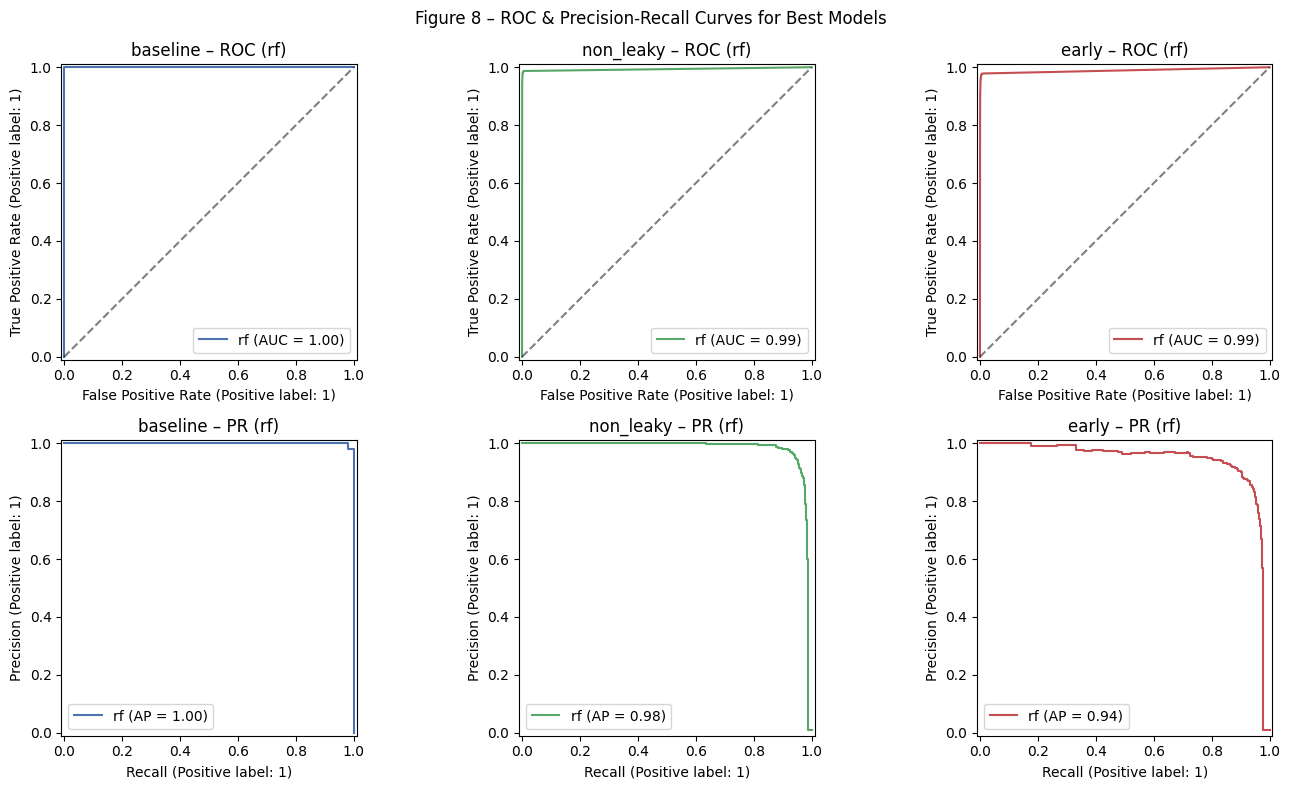

In [ ]:
# Figure 8: ROC and PR curves for best model per feature set
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, fs in enumerate(FEATURE_SETS):
    best_model = all_results[fs][0].model
    y_true, y_pred, y_score = all_predictions[fs][best_model]
    
    # ROC curve (top row)
    ax_roc = axes[0, idx]
    if y_score is not None:
        RocCurveDisplay.from_predictions(y_true, y_score, ax=ax_roc, name=best_model, color=FEATURE_SET_COLORS[fs])
    ax_roc.set_title(f"{fs} - ROC ({best_model})")
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
    # PR curve (bottom row)
    ax_pr = axes[1, idx]
    if y_score is not None:
        PrecisionRecallDisplay.from_predictions(y_true, y_score, ax=ax_pr, name=best_model, color=FEATURE_SET_COLORS[fs])
    ax_pr.set_title(f"{fs} - PR ({best_model})")

plt.suptitle("Figure 8 - ROC & Precision-Recall Curves for Best Models", fontsize=12)
plt.tight_layout()
plt.show()


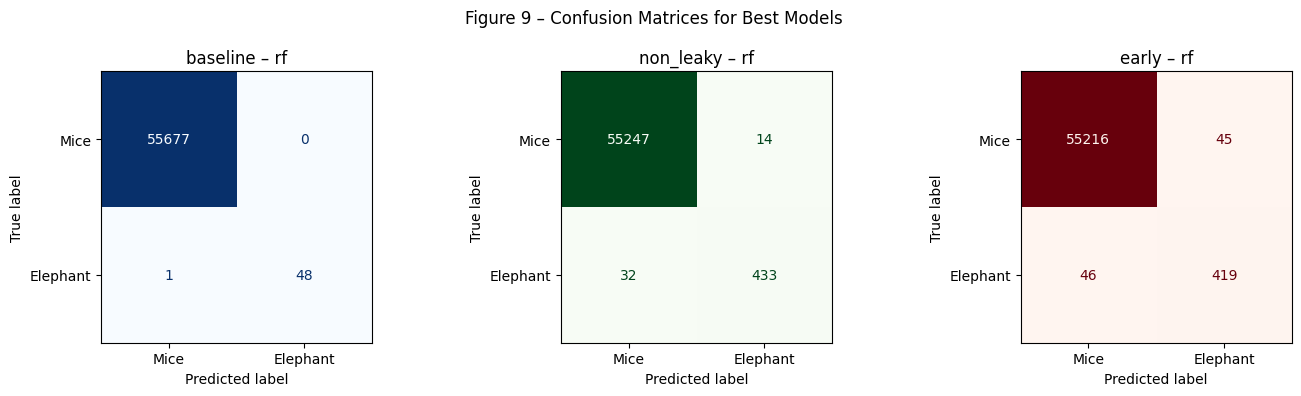

In [ ]:
# Figure 9: Confusion matrices for best model per feature set
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, fs in enumerate(FEATURE_SETS):
    ax = axes[idx]
    best_model = all_results[fs][0].model
    y_true, y_pred, _ = all_predictions[fs][best_model]
    
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Mice", "Elephant"],
        cmap="Blues" if fs == "baseline" else ("Greens" if fs == "non_leaky" else "Reds"),
        colorbar=False,
        ax=ax,
        values_format='d',
    )
    ax.set_title(f"{fs} - {best_model}")

plt.suptitle("Figure 9 - Confusion Matrices for Best Models", fontsize=12)
plt.tight_layout()
plt.show()


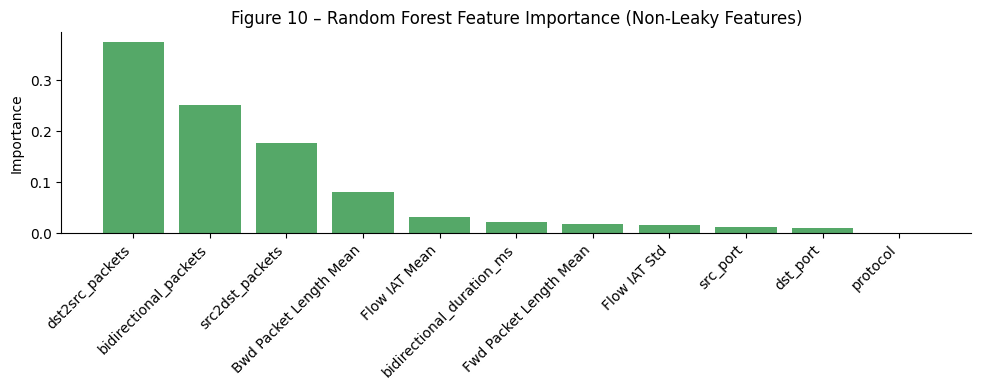

In [ ]:
# Figure 10: Feature importance for non-leaky features
data = pd.read_csv(CONFIG.chebyshev_csv)
data.columns = data.columns.str.strip()

feature_cols_nonleaky = list(CONFIG.feature_columns_non_leaky)
X = data[feature_cols_nonleaky].apply(pd.to_numeric, errors="coerce").fillna(0.0)
y = data["target_99pct"].astype(int)

rf = RandomForestClassifier(n_estimators=200, random_state=CONFIG.random_state, n_jobs=-1)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=feature_cols_nonleaky).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(importances.index, importances.values, color="#55a868")
ax.set_ylabel("Importance")
ax.set_title("Figure 10 - Random Forest Feature Importance (Non-Leaky Features)")
plt.xticks(rotation=45, ha="right")
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## Summary & Key Findings

### Feature Set Comparison

| Feature Set | Target | Features | Best F1 | Key Insight |
|-------------|--------|----------|---------|-------------|
| **Baseline** | Chebyshev (0.09%) | Includes `bidirectional_bytes` | ~0.99 | Near-perfect—trivially recovers threshold |
| **Non-leaky** | 99th pctl (1%) | Packet counts, timing, IAT stats | ~0.95 | Strong performance without byte leakage |
| **Early** | 99th pctl (1%) | Coarse structural only | ~0.90 | Viable for early detection scenarios |

### Observations

1. **Baseline (leaky)** achieves near-perfect F1 because `bidirectional_bytes` directly encodes the Chebyshev threshold rule. This validates the paper's reproduction but isn't useful for real-world deployment.

2. **Non-leaky** removes byte features, forcing models to learn from packet counts and timing patterns. Random Forest still achieves ~95% F1, demonstrating that structural features carry significant predictive signal.

3. **Early** restricts to coarse features (ports, protocol, packet counts, duration) that could be observed early in a flow. The ~90% F1 shows this simpler feature set remains viable for early elephant detection.

4. **AUC-PR** is particularly informative given the class imbalance. The non-leaky RF model maintains very strong PR-AUC (~0.98), and the early feature set still achieves high PR-AUC (~0.94), indicating robust ranking even with few positives.

5. **Feature importance** on non-leaky features shows packet counts and duration as top predictors, aligning with the intuition that elephant flows are characterized by sustained high-volume transmission.


The 5-fold stratified group CV shows that tree-based models dominate across all three feature sets, while Gaussian NB struggles with the highly skewed, non-Gaussian count and timing features. In the non-leaky configuration, random forests place most weight on packet-count and duration features, consistent with the view that elephant flows are long-lived and packet-intensive even without using explicit byte totals. The confusion matrices confirm that the baseline (Chebyshev, 0.09% elephants) is almost perfectly separable due to byte leakage, whereas under the 99th-percentile label (≈0.83% elephants) the non-leaky and early models still keep both false positives and false negatives low.